# Train the Defect Segmentation Model

train YOLO segmentation สำหรับ defect 4 classes จาก `dataset_defect` โดยใช้ split เดียวกับงาน panel

ผลที่บันทึกมี checkpoint, overall metrics, per-class metrics, confusion matrix และ training curves เพื่อดู class ที่ยังอ่อนแยกจากค่าเฉลี่ยรวม


## Setup และเช็ก GPU


In [1]:
from google.colab import drive
drive.mount('/content/drive')

%pip install -q ultralytics pyyaml pandas matplotlib seaborn tqdm

import torch

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    raise RuntimeError("CUDA GPU is required for Stage 2 training. In Colab, set Runtime > Change runtime type > T4 GPU.")


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.3 MB/s eta 0:00:00
CUDA available: True
GPU: Tesla T4


## Training config สำหรับ defect model


In [2]:
from pathlib import Path
import os
import json
import shutil
import glob
import math
from collections import Counter, defaultdict

import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Toggle this for a quick Colab sanity check. Full training must use False.
SMOKE_TEST = False

DRIVE_ROOT = Path('/content/drive/MyDrive/ai builders')
DATASET_DIR = DRIVE_ROOT / 'dataset' / 'dataset_defect'
DATA_YAML = DATASET_DIR / 'data.yaml'
DRIVE_RUNS = DRIVE_ROOT / 'runs'

FULL_RUN_NAME = 'stage2_defect_v1'
SMOKE_RUN_NAME = 'stage2_defect_smoke'
RUN_NAME = SMOKE_RUN_NAME if SMOKE_TEST else FULL_RUN_NAME
RUN_DIR = DRIVE_RUNS / RUN_NAME
FINAL_DIR = DRIVE_RUNS / (f'{RUN_NAME}_final' if SMOKE_TEST else f'{FULL_RUN_NAME}_final')
LAST_CKPT = RUN_DIR / 'weights' / 'last.pt'
BEST_CKPT = RUN_DIR / 'weights' / 'best.pt'

IMG_SIZE = 640  # matches the 640 x 640 exported dataset resolution
BATCH = 4 if SMOKE_TEST else 16  # full training value; smoke mode uses a smaller value
EPOCHS = 1 if SMOKE_TEST else 100  # full training value; smoke mode uses a smaller value
PATIENCE = 1 if SMOKE_TEST else 20  # full training value; smoke mode uses a smaller value
WORKERS = 2 if SMOKE_TEST else 8  # full training value; smoke mode uses a smaller value
SEED = 42  # fixed for reproducible sampling and training

EXPECTED_NAMES = {
    0: 'dust',
    1: 'bird_drop',
    2: 'physical_damage',
    3: 'leaf',
}

DRIVE_RUNS.mkdir(parents=True, exist_ok=True)

print("Stage 2 defect training config")
print(f"  DATA_YAML: {DATA_YAML}")
print(f"  SMOKE_TEST: {SMOKE_TEST}")
print(f"  RUN_DIR: {RUN_DIR}")
print(f"  FINAL_DIR: {FINAL_DIR}")
print(f"  imgsz={IMG_SIZE}, batch={BATCH}, epochs={EPOCHS}, patience={PATIENCE}, seed={SEED}")
if SMOKE_TEST:
    print("SMOKE_TEST is enabled. This run is only for install/dataset/training sanity checks.")


Stage 2 defect training config
  DATA_YAML: /content/drive/MyDrive/ai builders/dataset/dataset_defect/data.yaml
  SMOKE_TEST: False
  RUN_DIR: /content/drive/MyDrive/ai builders/runs/stage2_defect_v1
  FINAL_DIR: /content/drive/MyDrive/ai builders/runs/stage2_defect_v1_final
  imgsz=640, batch=16, epochs=100, patience=20, seed=42


## ตรวจ defect images, labels และ class balance

Train/validation ยังใช้เฉพาะภาพที่มี defect เหมือนตอนฝึกโมเดลเดิม ส่วน test มีครบ 230 ภาพ โดย clean images 31 ภาพใช้ empty label เพื่อวัด false positives ของ Stage 2


In [3]:
def require_file(path, hint=''):
    path = Path(path)
    if not path.exists():
        msg = f"Missing required file: {path}"
        if hint:
            msg += f"\nHint: {hint}"
        raise FileNotFoundError(msg)
    return path


def require_dir(path, hint=''):
    path = Path(path)
    if not path.exists() or not path.is_dir():
        msg = f"Missing required directory: {path}"
        if hint:
            msg += f"\nHint: {hint}"
        raise FileNotFoundError(msg)
    return path


def normalize_names(names):
    if isinstance(names, dict):
        return {int(k): str(v) for k, v in names.items()}
    if isinstance(names, list):
        return {i: str(v) for i, v in enumerate(names)}
    raise TypeError(f"Unsupported names format: {type(names)}")


def image_files(folder):
    folder = Path(folder)
    files = []
    for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
        files.extend(folder.glob(ext))
    return sorted(files)


def parse_yolo_seg_label(path, allow_empty=False):
    """Parse one YOLO segmentation label; test negatives may be empty."""
    rows = []
    text = Path(path).read_text().strip()
    if not text:
        if allow_empty:
            return rows
        raise ValueError(f"Empty label file: {path}")

    for line_no, line in enumerate(text.splitlines(), start=1):
        parts = line.strip().split()
        if len(parts) < 7:
            raise ValueError(
                f"Invalid segmentation line with fewer than 3 points: "
                f"{path}:{line_no}"
            )
        if len(parts) % 2 != 1:
            raise ValueError(
                f"Invalid coordinate pair count: {path}:{line_no}"
            )
        try:
            class_id = int(float(parts[0]))
            coords = [float(x) for x in parts[1:]]
        except ValueError as exc:
            raise ValueError(
                f"Non-numeric label value: {path}:{line_no}"
            ) from exc
        if class_id not in EXPECTED_NAMES:
            raise ValueError(
                f"dataset_defect must contain only classes 0..3, "
                f"found {class_id}: {path}:{line_no}"
            )
        if any((coord < -1e-6 or coord > 1 + 1e-6) for coord in coords):
            raise ValueError(
                f"Coordinates outside [0, 1]: {path}:{line_no}"
            )
        rows.append({
            'class_id': class_id,
            'class_name': EXPECTED_NAMES[class_id],
            'n_points': len(coords) // 2,
        })
    return rows


require_file(
    DATA_YAML,
    'Run 05_grouped_split.ipynb first to create dataset_defect/data.yaml.',
)
with open(DATA_YAML, 'r') as handle:
    cfg = yaml.safe_load(handle)

class_names = normalize_names(cfg.get('names'))
print(f"Classes ({cfg.get('nc')}): {class_names}")
assert int(cfg['nc']) == 4, "Stage 2 must have exactly 4 defect classes."
assert class_names == EXPECTED_NAMES, (
    f"Stage 2 classes must be {EXPECTED_NAMES}, got {class_names}"
)

validation_rows = []
label_records = []


Classes (4): {0: 'dust', 1: 'bird_drop', 2: 'physical_damage', 3: 'leaf'}


### สรุป label validity และ class balance


In [4]:
for split in ['train', 'val', 'test']:
    img_dir = require_dir(DATASET_DIR / 'images' / split)
    lbl_dir = require_dir(DATASET_DIR / 'labels' / split)
    imgs = image_files(img_dir)
    if not imgs:
        raise ValueError(f"No images found for split {split}: {img_dir}")

    missing_labels = []
    empty_label_count = 0
    instance_count = 0
    point_counts = []
    split_counts = Counter()

    for img_path in tqdm(imgs, desc=f'validate {split}'):
        label_path = lbl_dir / f'{img_path.stem}.txt'
        if not label_path.exists():
            missing_labels.append(img_path.name)
            continue

        is_empty_label = not label_path.read_text().strip()
        empty_label_count += int(is_empty_label)
        label_rows = parse_yolo_seg_label(
            label_path,
            allow_empty=(split == 'test'),
        )
        instance_count += len(label_rows)

        for row in label_rows:
            point_counts.append(row['n_points'])
            split_counts[row['class_id']] += 1
            label_records.append({
                'split': split,
                'filename': img_path.name,
                'class_id': row['class_id'],
                'class_name': row['class_name'],
                'n_points': row['n_points'],
            })

    if missing_labels:
        raise FileNotFoundError(
            f"Missing {len(missing_labels)} labels in {split}. "
            f"Examples: {missing_labels[:5]}"
        )

    row = {
        'split': split,
        'images': len(imgs),
        'labels': len(list(lbl_dir.glob('*.txt'))),
        'empty_labels': empty_label_count,
        'instances': instance_count,
        'min_points': int(min(point_counts)) if point_counts else 0,
        'mean_points': float(np.mean(point_counts)) if point_counts else 0.0,
    }
    for class_id, name in class_names.items():
        row[name] = int(split_counts[class_id])
    validation_rows.append(row)

validation_df = pd.DataFrame(validation_rows)
validation_by_split = validation_df.set_index('split')

if int(validation_by_split.loc['test', 'images']) != 230:
    raise AssertionError(
        'Stage 2 test must contain all 230 grouped-test images. '
        'Rerun 05_grouped_split.ipynb with the updated export cell.'
    )
if int(validation_by_split.loc['test', 'empty_labels']) != 31:
    raise AssertionError(
        'Stage 2 test must contain 31 clean images with empty labels.'
    )
if int(validation_by_split.loc['train', 'empty_labels']) != 0:
    raise AssertionError('Stage 2 train must not contain empty labels.')
if int(validation_by_split.loc['val', 'empty_labels']) != 0:
    raise AssertionError('Stage 2 validation must not contain empty labels.')

label_df = pd.DataFrame(label_records)
class_dist = (
    label_df.groupby(['split', 'class_name'])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=['train', 'val', 'test'],
        columns=list(class_names.values()),
        fill_value=0,
    )
)
train_counts = class_dist.loc['train']
imbalance_ratio = float(train_counts.max() / max(train_counts.min(), 1))

display(validation_df)
print("Class distribution by split:")
display(class_dist)
print(f"Train imbalance ratio: {imbalance_ratio:.2f}x")
print("dataset_defect validation passed: test=230, clean negatives=31.")


validate train:   0%|          | 0/1609 [00:00<?, ?it/s]

validate val:   0%|          | 0/176 [00:00<?, ?it/s]

validate test:   0%|          | 0/230 [00:00<?, ?it/s]

,split,images,labels,empty_labels,instances,min_points,mean_points,dust,bird_drop,physical_damage,leaf
0,train,1609,1609,0,13383,3,16.255698,4036,5133,1949,2265
1,val,176,176,0,1435,3,16.092683,418,480,250,287
2,test,230,230,31,1516,3,13.938654,413,507,305,291


Class distribution by split:


class_name,dust,bird_drop,physical_damage,leaf
split,,,,
train,4036,5133,1949,2265
val,418,480,250,287
test,413,507,305,291


Train imbalance ratio: 2.63x
dataset_defect validation passed: test=230, clean negatives=31.


## Train หรือ resume defect model


In [ ]:
from ultralytics import YOLO

train_config = {
    'data': str(DATA_YAML),
    'imgsz': IMG_SIZE,
    'batch': BATCH,
    'epochs': EPOCHS,
    'patience': PATIENCE,
    'optimizer': 'auto',
    'lr0': 0.01,
    'lrf': 0.01,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3,

    # Loss weights. Ultralytics YOLO11 segmentation does not support direct per-class weights.
    'box': 7.5,
    'cls': 1.0,
    'dfl': 1.5,

    # Strong augmentation for small/diverse defect masks.
    'hsv_h': 0.015,
    'hsv_s': 0.7,
    'hsv_v': 0.4,
    'degrees': 15.0,
    'translate': 0.1,
    'scale': 0.5,
    'fliplr': 0.5,
    'flipud': 0.5,
    'mosaic': 1.0,
    'mixup': 0.1,
    'copy_paste': 0.3,

    'project': str(DRIVE_RUNS),
    'name': RUN_NAME,
    'exist_ok': True,
    'save': True,
    'save_period': 10 if not SMOKE_TEST else -1,
    'device': 0,
    'workers': WORKERS,
    'seed': SEED,
    'plots': True,
}

try:
    if (not SMOKE_TEST) and LAST_CKPT.exists():
        print(f"Resuming from {LAST_CKPT}")
        model = YOLO(str(LAST_CKPT))
        results = model.train(resume=True)
    else:
        if SMOKE_TEST:
            print("Fresh smoke-test training from yolo11s-seg.pt")
        else:
            print("Fresh full training from yolo11s-seg.pt")
        model = YOLO('yolo11s-seg.pt')
        results = model.train(**train_config)
except RuntimeError as exc:
    if 'out of memory' in str(exc).lower() or 'cuda' in str(exc).lower():
        print("Training hit a CUDA/runtime error. If this is OOM, change BATCH from 16 to 8 and rerun this cell.")
    raise

print(f"Training done. Run directory: {RUN_DIR}")
print(f"Best checkpoint: {BEST_CKPT}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Fresh full training from yolo11s-seg.pt
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/ai builders/dataset/dataset_defect/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript,

## วัดผลบน test 230 ภาพด้วย checkpoint ที่ดีที่สุด

Cell นี้โหลด `best.pt` จาก Drive โดยตรง จึงรันได้หลังเปิด runtime ใหม่แม้ข้าม training cell ด้านบน ผลที่ได้ใช้โมเดลเดิม แต่ประเมิน test ครบทั้งภาพที่มี defect และ clean negatives


In [5]:
from ultralytics import YOLO

require_file(BEST_CKPT, 'Training must create weights/best.pt before evaluation.')

best_model = YOLO(str(BEST_CKPT))

test_results = best_model.val(
    data=str(DATA_YAML),
    split='test',
    imgsz=IMG_SIZE,
    batch=BATCH,
    save_json=True,
    plots=True,
    project=str(DRIVE_RUNS),
    name=f'{RUN_NAME}_test_eval',
    exist_ok=True,
)

seg = test_results.seg
n_classes = len(class_names)

def metric_array(metric_obj, attr_names, n, fill=np.nan):
    for attr in attr_names:
        value = getattr(metric_obj, attr, None)
        if value is None or callable(value):
            continue
        try:
            arr = np.asarray(value, dtype=float).reshape(-1)
        except Exception:
            continue
        if arr.size >= n:
            return arr[:n]
    return np.full(n, fill, dtype=float)

per_class_precision = metric_array(seg, ['p', 'precision'], n_classes)
per_class_recall = metric_array(seg, ['r', 'recall'], n_classes)
per_class_map50 = metric_array(seg, ['ap50'], n_classes)
per_class_map50_95 = metric_array(seg, ['maps', 'ap'], n_classes)
per_class_f1 = np.divide(
    2 * per_class_precision * per_class_recall,
    per_class_precision + per_class_recall,
    out=np.full(n_classes, np.nan),
    where=(per_class_precision + per_class_recall) > 0,
)

per_class_metrics_df = pd.DataFrame({
    'class_id': list(class_names.keys()),
    'class_name': list(class_names.values()),
    'precision': per_class_precision,
    'recall': per_class_recall,
    'f1': per_class_f1,
    'mask_mAP50': per_class_map50,
    'mask_mAP50_95': per_class_map50_95,
})

metrics = {
    'test_box_mAP50': float(test_results.box.map50),
    'test_box_mAP50_95': float(test_results.box.map),
    'test_mask_mAP50': float(seg.map50),
    'test_mask_mAP50_95': float(seg.map),
    'test_mask_precision': float(seg.mp),
    'test_mask_recall': float(seg.mr),
    'test_macro_f1': float(np.nanmean(per_class_f1)),
    'test_macro_recall': float(np.nanmean(per_class_recall)),
}

per_class_metrics_path = RUN_DIR / 'per_class_metrics.csv'
per_class_metrics_df.to_csv(per_class_metrics_path, index=False)

print("Stage 2 - Defect Detection Test Results")
print(f"Box mAP@0.5:        {metrics['test_box_mAP50']:.4f}")
print(f"Box mAP@0.5:0.95:   {metrics['test_box_mAP50_95']:.4f}")
print(f"Mask mAP@0.5:       {metrics['test_mask_mAP50']:.4f}")
print(f"Mask mAP@0.5:0.95:  {metrics['test_mask_mAP50_95']:.4f}")
print(f"Mask Precision:     {metrics['test_mask_precision']:.4f}")
print(f"Mask Recall:        {metrics['test_mask_recall']:.4f}")
print(f"Macro F1:           {metrics['test_macro_f1']:.4f}")
print(f"Macro Recall:       {metrics['test_macro_recall']:.4f}")
print("Per-class defect metrics:")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s-seg summary (fused): 114 layers, 10,068,364 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.6 ms, read: 0.2±0.1 MB/s, size: 71.3 KB)
val: Scanning /content/drive/MyDrive/ai builders/dataset/dataset_defect/labels/test... 230 images, 31 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 230/230 103.6it/s 2.2s
val: New cache created: /content/drive/MyDrive/ai builders/dataset/dataset_defect/labels/test.cache
requirements: Ultralytics requirement ['faster-coco-eval>=1.6.7'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 261m

### ตรวจ per-class defect metrics

แสดง precision, recall, mAP และ F1 แยก class เพื่อไม่ให้ minority defects ถูก aggregate metric กลบ


In [6]:
display(per_class_metrics_df)
print(f"Saved per-class metrics: {per_class_metrics_path}")


,class_id,class_name,precision,recall,f1,mask_mAP50,mask_mAP50_95
0,0,dust,0.715175,0.786925,0.749336,0.790482,0.532604
1,1,bird_drop,0.693593,0.469428,0.559907,0.560707,0.241817
2,2,physical_damage,0.911803,0.915193,0.913495,0.951568,0.488493
3,3,leaf,0.919452,0.862990,0.890327,0.925386,0.555853


Saved per-class metrics: /content/drive/MyDrive/ai builders/runs/stage2_defect_v1/per_class_metrics.csv


## ตัวอย่าง defect predictions

เลือกภาพจาก test split ให้ครอบคลุม defect classes ก่อน แล้วแสดงภาพต้นฉบับเทียบกับ segmentation predictions จาก `best.pt`


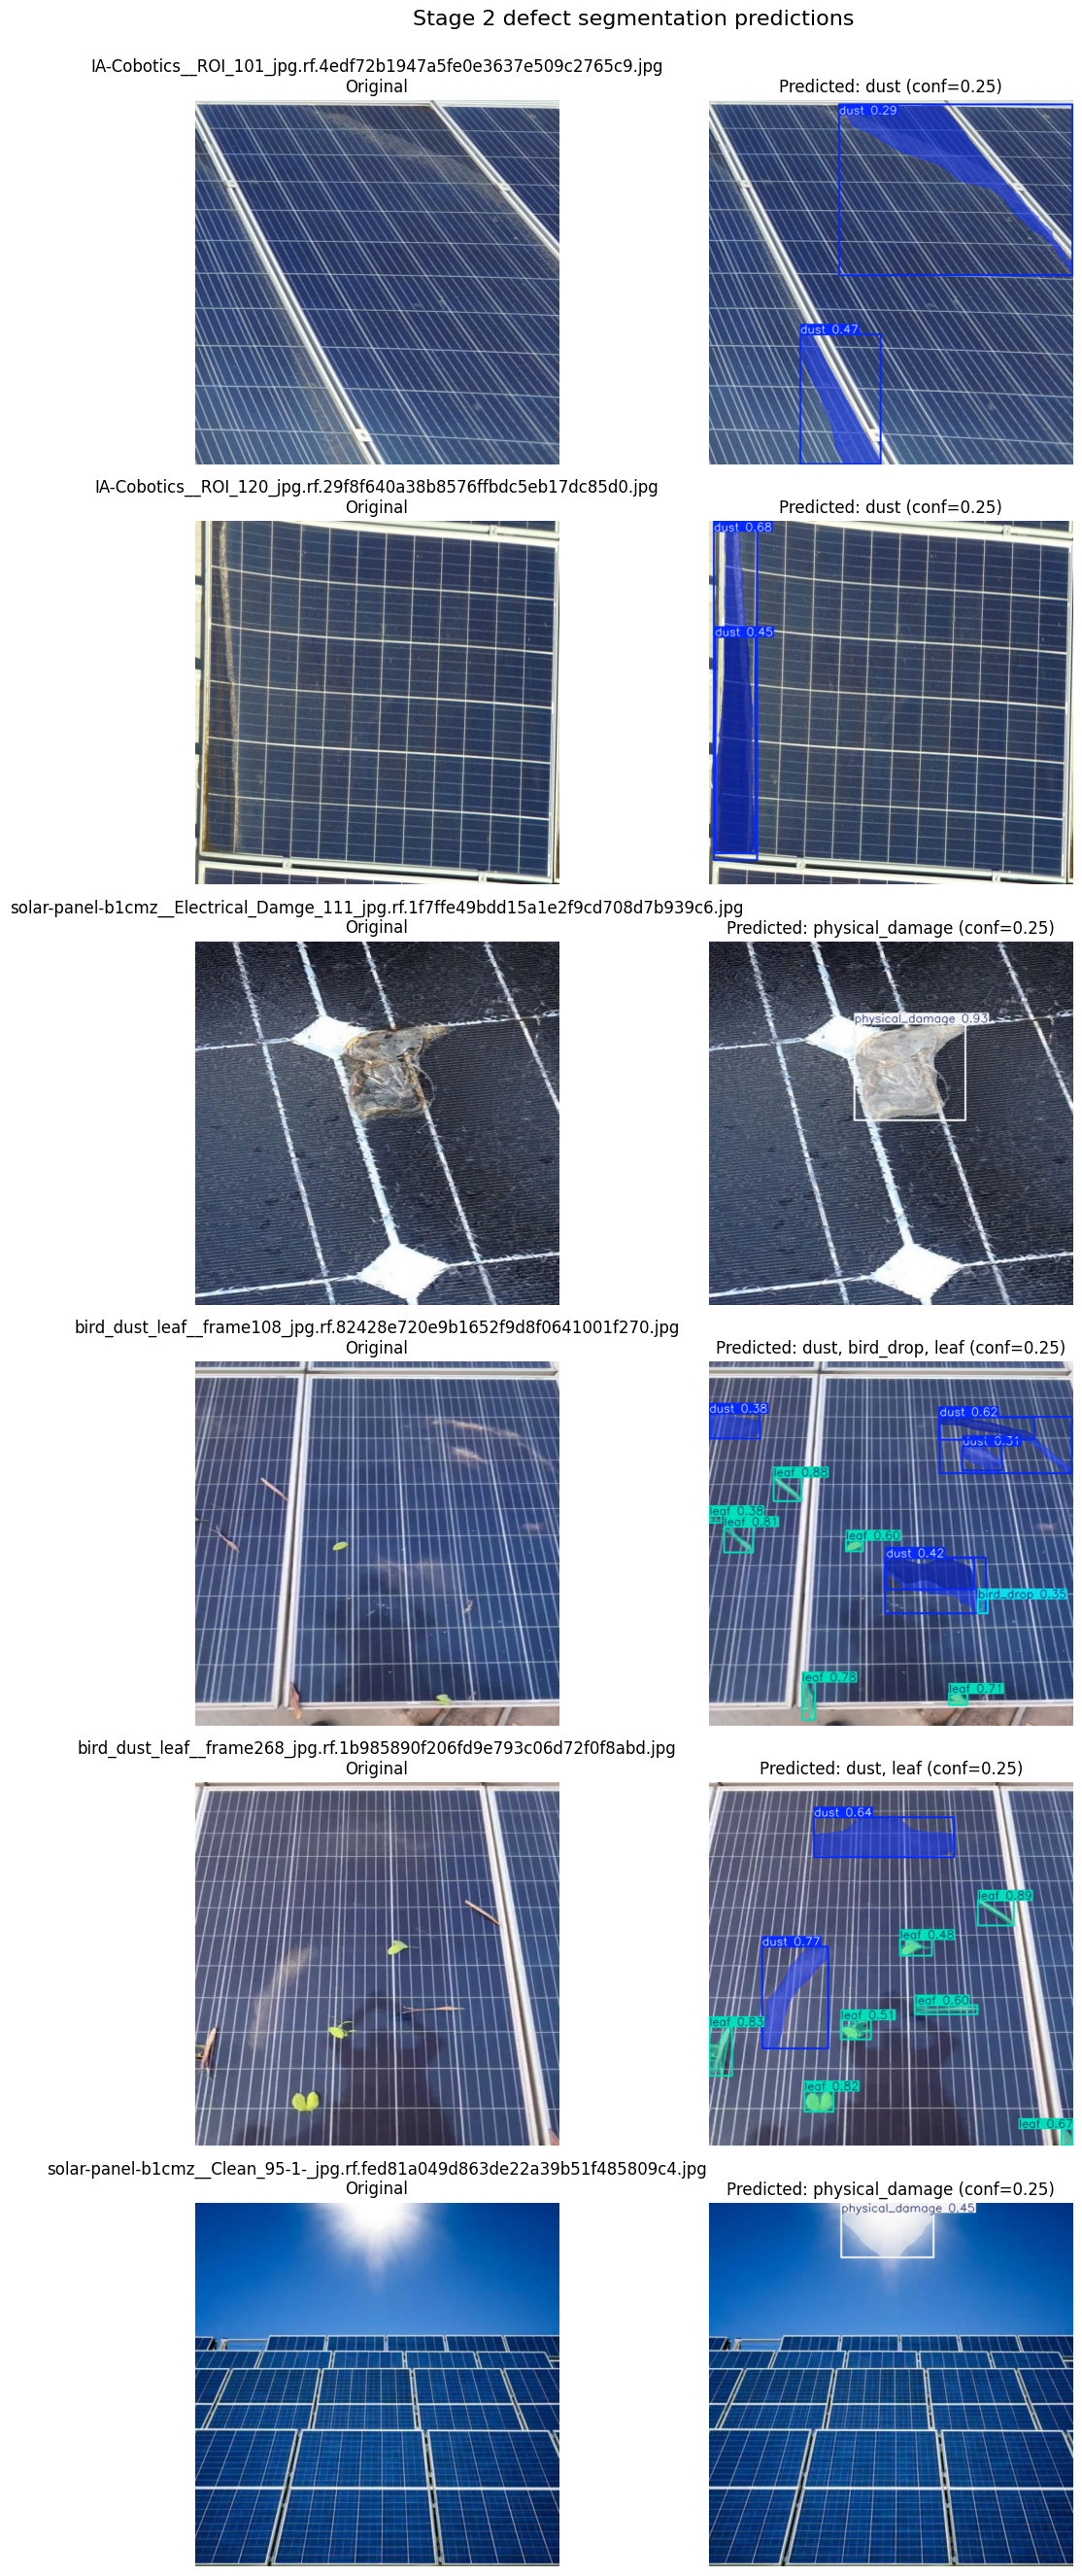

Saved prediction gallery: /content/drive/MyDrive/ai builders/runs/stage2_defect_v1/prediction_gallery.png


In [7]:
test_images = image_files(DATASET_DIR / 'images' / 'test')
test_label_dir = DATASET_DIR / 'labels' / 'test'
if not test_images:
    raise ValueError('No test images found for prediction gallery.')

gallery_images = []
for class_id in class_names:
    for image_path in test_images:
        label_path = test_label_dir / f'{image_path.stem}.txt'
        if not label_path.exists():
            continue
        label_class_ids = {
            int(float(line.split()[0]))
            for line in label_path.read_text().splitlines()
            if line.strip()
        }
        if class_id in label_class_ids and image_path not in gallery_images:
            gallery_images.append(image_path)
            break

target_gallery_size = min(6, len(test_images))
fallback_indices = np.linspace(
    0, len(test_images) - 1, num=target_gallery_size, dtype=int
)
for index in fallback_indices:
    image_path = test_images[index]
    if image_path not in gallery_images:
        gallery_images.append(image_path)
    if len(gallery_images) >= target_gallery_size:
        break

PREDICTION_GALLERY_CONF = 0.25
gallery_results = best_model.predict(
    source=[str(path) for path in gallery_images],
    conf=PREDICTION_GALLERY_CONF,
    imgsz=IMG_SIZE,
    retina_masks=True,
    verbose=False,
    device=0,
)

fig, axes = plt.subplots(
    len(gallery_images),
    2,
    figsize=(12, 4.5 * len(gallery_images)),
    squeeze=False,
)
for row_index, (image_path, result) in enumerate(
    zip(gallery_images, gallery_results)
):
    original_rgb = result.orig_img[..., ::-1]
    prediction_rgb = result.plot()[..., ::-1]
    predicted_classes = []
    if result.boxes is not None and result.boxes.cls is not None:
        class_ids = result.boxes.cls.detach().cpu().numpy().astype(int)
        predicted_classes = [
            class_names[class_id] for class_id in sorted(set(class_ids))
        ]
    class_text = ', '.join(predicted_classes) or 'no defect'

    axes[row_index, 0].imshow(original_rgb)
    axes[row_index, 0].set_title(f'{image_path.name}\nOriginal')
    axes[row_index, 1].imshow(prediction_rgb)
    axes[row_index, 1].set_title(
        f'Predicted: {class_text} '
        f'(conf={PREDICTION_GALLERY_CONF:.2f})'
    )
    axes[row_index, 0].axis('off')
    axes[row_index, 1].axis('off')

fig.suptitle('Stage 2 defect segmentation predictions', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.98])
PREDICTION_GALLERY_PATH = RUN_DIR / 'prediction_gallery.png'
fig.savefig(PREDICTION_GALLERY_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved prediction gallery: {PREDICTION_GALLERY_PATH}')


**คำอธิบายรูป:** ตัวอย่าง test images ที่ครอบคลุม defect classes ใช้ตรวจตำแหน่งและรูปร่าง mask ควบคู่กับ per-class metrics โดยเฉพาะวัตถุขนาดเล็กอย่าง `bird_drop`


## Confusion matrix


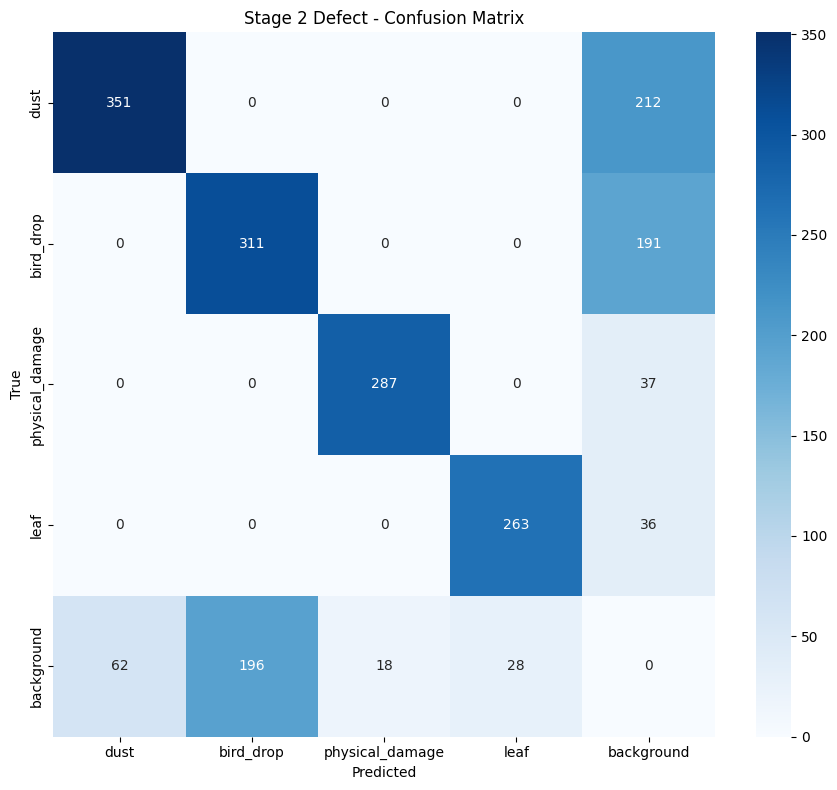

,dust,bird_drop,physical_damage,leaf,background
dust,351.0,0.0,0.0,0.0,212.0
bird_drop,0.0,311.0,0.0,0.0,191.0
physical_damage,0.0,0.0,287.0,0.0,37.0
leaf,0.0,0.0,0.0,263.0,36.0
background,62.0,196.0,18.0,28.0,0.0


Saved confusion matrix: /content/drive/MyDrive/ai builders/runs/stage2_defect_v1/confusion_matrix.png


In [8]:
confusion_matrix_path = RUN_DIR / 'confusion_matrix.png'
cm_df = None

if getattr(test_results, 'confusion_matrix', None) is not None:
    cm = np.asarray(test_results.confusion_matrix.matrix)
    labels = list(class_names.values()) + ['background']
    cm_df = pd.DataFrame(cm, index=labels[:cm.shape[0]], columns=labels[:cm.shape[1]])

    fig, ax = plt.subplots(figsize=(9, 8))
    sns.heatmap(cm_df, annot=True, fmt='.0f', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Stage 2 Defect - Confusion Matrix')
    plt.tight_layout()
    plt.savefig(confusion_matrix_path, dpi=120)
    plt.show()
    display(cm_df)
    print(f"Saved confusion matrix: {confusion_matrix_path}")
else:
    print("No confusion matrix object found in test_results.")


## Training curves


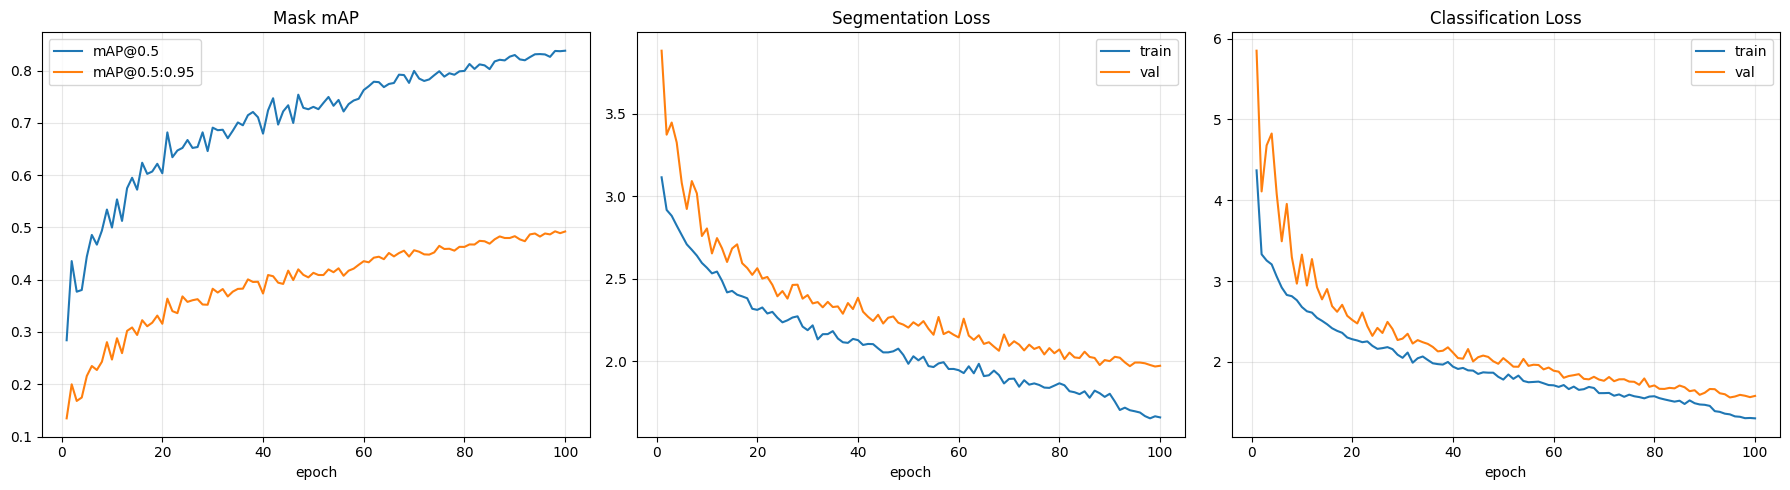

Best epoch by Mask mAP@0.5: 100 (0.8379)
Saved training curves: /content/drive/MyDrive/ai builders/runs/stage2_defect_v1/training_curves.png


In [9]:
results_csv = require_file(RUN_DIR / 'results.csv', 'Ultralytics should create results.csv after training.')
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

required_cols = [
    'epoch',
    'metrics/mAP50(M)',
    'metrics/mAP50-95(M)',
    'train/seg_loss',
    'val/seg_loss',
    'train/cls_loss',
    'val/cls_loss',
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"results.csv missing expected columns: {missing}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(df['epoch'], df['metrics/mAP50(M)'], label='mAP@0.5')
axes[0].plot(df['epoch'], df['metrics/mAP50-95(M)'], label='mAP@0.5:0.95')
axes[0].set_title('Mask mAP')
axes[0].set_xlabel('epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['epoch'], df['train/seg_loss'], label='train')
axes[1].plot(df['epoch'], df['val/seg_loss'], label='val')
axes[1].set_title('Segmentation Loss')
axes[1].set_xlabel('epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(df['epoch'], df['train/cls_loss'], label='train')
axes[2].plot(df['epoch'], df['val/cls_loss'], label='val')
axes[2].set_title('Classification Loss')
axes[2].set_xlabel('epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
curves_path = RUN_DIR / 'training_curves.png'
plt.savefig(curves_path, dpi=120)
plt.show()

best_epoch_row = df.loc[df['metrics/mAP50(M)'].idxmax()]
best_epoch = int(best_epoch_row['epoch'])
best_epoch_mask_map50 = float(best_epoch_row['metrics/mAP50(M)'])
print(f"Best epoch by Mask mAP@0.5: {best_epoch} ({best_epoch_mask_map50:.4f})")
print(f"Saved training curves: {curves_path}")


## เก็บ checkpoint และ metrics


In [10]:
FINAL_DIR.mkdir(parents=True, exist_ok=True)

artifact_map = {
    RUN_DIR / 'weights' / 'best.pt': FINAL_DIR / 'best.pt',
    RUN_DIR / 'weights' / 'last.pt': FINAL_DIR / 'last.pt',
    RUN_DIR / 'results.csv': FINAL_DIR / 'results.csv',
    RUN_DIR / 'training_curves.png': FINAL_DIR / 'training_curves.png',
    RUN_DIR / 'confusion_matrix.png': FINAL_DIR / 'confusion_matrix.png',
    RUN_DIR / 'args.yaml': FINAL_DIR / 'args.yaml',
    RUN_DIR / 'per_class_metrics.csv': FINAL_DIR / 'per_class_metrics.csv',
    RUN_DIR / 'prediction_gallery.png': FINAL_DIR / 'prediction_gallery.png',
}

copied = []
missing_artifacts = []
for src, dst in artifact_map.items():
    if src.exists():
        shutil.copy2(src, dst)
        copied.append(str(dst))
    else:
        missing_artifacts.append(str(src))

if not (FINAL_DIR / 'best.pt').exists():
    raise FileNotFoundError("best.pt was not copied to the final artifact folder.")

summary = {
    'stage': 'Stage 2 - Defect Detection',
    'model': 'yolo11s-seg.pt',
    'run_name': RUN_NAME,
    'smoke_test': bool(SMOKE_TEST),
    'dataset_yaml': str(DATA_YAML),
    'dataset_validation': validation_df.to_dict(orient='records'),
    'class_distribution_by_split': class_dist.reset_index().to_dict(orient='records'),
    'train_imbalance_ratio': imbalance_ratio,
    'classes': class_names,
    'imgsz': IMG_SIZE,
    'batch': BATCH,
    'epochs': EPOCHS,
    'patience': PATIENCE,
    'seed': SEED,
    **metrics,
    'per_class_metrics': per_class_metrics_df.to_dict(orient='records'),
    'prediction_gallery': str(FINAL_DIR / 'prediction_gallery.png'),
    'best_epoch_by_mask_map50': int(best_epoch),
    'best_epoch_mask_map50': float(best_epoch_mask_map50),
    'run_dir': str(RUN_DIR),
    'final_dir': str(FINAL_DIR),
    'copied_artifacts': copied,
    'missing_optional_artifacts': missing_artifacts,
}

summary_path = FINAL_DIR / 'stage2_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Saved summary: {summary_path}")
print("Copied artifacts:")
for item in copied:
    print(f"  {item}")
if missing_artifacts:
    print("Missing optional artifacts:")
    for item in missing_artifacts:
        print(f"  {item}")


Saved summary: /content/drive/MyDrive/ai builders/runs/stage2_defect_v1_final/stage2_summary.json
Copied artifacts:
  /content/drive/MyDrive/ai builders/runs/stage2_defect_v1_final/best.pt
  /content/drive/MyDrive/ai builders/runs/stage2_defect_v1_final/last.pt
  /content/drive/MyDrive/ai builders/runs/stage2_defect_v1_final/results.csv
  /content/drive/MyDrive/ai builders/runs/stage2_defect_v1_final/training_curves.png
  /content/drive/MyDrive/ai builders/runs/stage2_defect_v1_final/confusion_matrix.png
  /content/drive/MyDrive/ai builders/runs/stage2_defect_v1_final/args.yaml
  /content/drive/MyDrive/ai builders/runs/stage2_defect_v1_final/per_class_metrics.csv
  /content/drive/MyDrive/ai builders/runs/stage2_defect_v1_final/prediction_gallery.png


## สรุป defect training


In [11]:
print("Defect segmentation training summary")
print(f"Run name:             {RUN_NAME}")
print(f"Smoke test:           {SMOKE_TEST}")
print(f"Dataset:              {DATA_YAML}")
print("Model:                yolo11s-seg.pt")
print(f"Classes:              {class_names}")
print("")
print("Test metrics:")
print(f"  Box mAP@0.5:        {metrics['test_box_mAP50']:.4f}")
print(f"  Box mAP@0.5:0.95:   {metrics['test_box_mAP50_95']:.4f}")
print(f"  Mask mAP@0.5:       {metrics['test_mask_mAP50']:.4f}")
print(f"  Mask mAP@0.5:0.95:  {metrics['test_mask_mAP50_95']:.4f}")
print(f"  Mask Precision:     {metrics['test_mask_precision']:.4f}")
print(f"  Mask Recall:        {metrics['test_mask_recall']:.4f}")
print(f"  Macro F1:           {metrics['test_macro_f1']:.4f}")
print(f"  Macro Recall:       {metrics['test_macro_recall']:.4f}")
print("")
print("Per-class metrics:")
display(per_class_metrics_df)
print("")
print(f"Best epoch by mask mAP@0.5: {best_epoch}")
print(f"Final artifacts:       {FINAL_DIR}")
print(f"Summary JSON:          {summary_path}")


Defect segmentation training summary
Run name:             stage2_defect_v1
Smoke test:           False
Dataset:              /content/drive/MyDrive/ai builders/dataset/dataset_defect/data.yaml
Model:                yolo11s-seg.pt
Classes:              {0: 'dust', 1: 'bird_drop', 2: 'physical_damage', 3: 'leaf'}

Test metrics:
  Box mAP@0.5:        0.8156
  Box mAP@0.5:0.95:   0.5068
  Mask mAP@0.5:       0.8070
  Mask mAP@0.5:0.95:  0.4547
  Mask Precision:     0.8100
  Mask Recall:        0.7586
  Macro F1:           0.7783
  Macro Recall:       0.7586

Per-class metrics:


,class_id,class_name,precision,recall,f1,mask_mAP50,mask_mAP50_95
0,0,dust,0.715175,0.786925,0.749336,0.790482,0.532604
1,1,bird_drop,0.693593,0.469428,0.559907,0.560707,0.241817
2,2,physical_damage,0.911803,0.915193,0.913495,0.951568,0.488493
3,3,leaf,0.919452,0.862990,0.890327,0.925386,0.555853



Best epoch by mask mAP@0.5: 100
Final artifacts:       /content/drive/MyDrive/ai builders/runs/stage2_defect_v1_final
Summary JSON:          /content/drive/MyDrive/ai builders/runs/stage2_defect_v1_final/stage2_summary.json
